In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

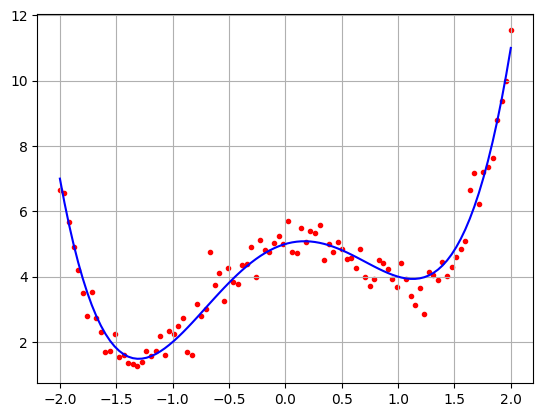

In [2]:
# generation of synthetic dataset

N = 100
x = np.linspace(-2, 2, N)
y = x ** 2 - 3
noise = np.random.normal(0, .5, N)

# original function
y0 = x**4 - 3* x**2 +x + 5

# "real data"
y = y0 + noise

plt.grid()
plt.scatter(x, y, marker = '.', color = 'r')
plt.plot(x, y0, color='b')

In [3]:
# Reshape for sklearn
x = x.reshape(-1, 1)

In [4]:
# Polynomial regression (degree=4, since the true function is quartic)
degree = 4
model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
model.fit(x, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomialfeatures', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",4
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [5]:
x_fit = np.linspace(-2, 2, 200).reshape(-1, 1)
y_fit = model.predict(x_fit)

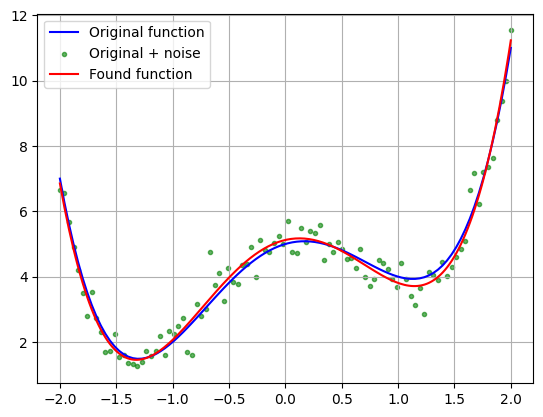

In [6]:
plt.grid()
plt.plot(x, y0, "b", label="Original function")
plt.scatter(x, y, color="g", marker =".", label="Original + noise", alpha=0.6)
plt.plot(x_fit, y_fit, "r", label="Found function")
plt.legend()

In [7]:
# accessing arguments found
linreg = model.named_steps["linearregression"]

In [8]:
# coefficients
linreg.coef_

array([ 0.        ,  0.79735723, -3.24189755,  0.07437794,  1.05540643])

In [9]:
# shift
linreg.intercept_

np.float64(5.122970204932907)

In [10]:
all = np.hstack(([linreg.intercept_], linreg.coef_[1:]))
all
#           5     +       x          + x^2    +    x^3     +    x^4

array([ 5.1229702 ,  0.79735723, -3.24189755,  0.07437794,  1.05540643])